In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Exploration

### Variables Originales del Dataset

**Original Dataset Variables**

**Week**: Covers a period of 100 weeks (approximately two years), from October 31 of 2016 to September 24 of 2018. Each week is identified by the date of the corresponding Monday.

**SKU (Stock Keeping Unit)**: Contains 44 distinct products, indexed from 1 to 44.

**Weekly_sales**: This is the target variable to be predicted; it represents the number of units sold of a specific SKU in a given week. **THE VARIABLE TO BE PREDICTED = TARGET = OUTCOME VARIABLE**

**Feat_main_page (Featured on main page)**: This is a binary indicator (True/False) that records whether the product was shown on the website's home page to increase its visibility during that week.

**Color**: Describes the product's color. There are nine colors (black, gold, pink, blue, red, gray, green, white, and purple). Some products have the value "none" if the color is not defined or the data is missing.

**Price**: Indicates the fixed price of the item during the week. The pricing team can adjust it weekly based on promotions or inventory levels.

**Vendor**: Represents the product's brand. The 44 SKUs belong to 10 different vendors, anonymized with numbers from 1 to 10.

**Functionality**: Describes the primary function of the SKU. There are 12 different categories, including mobile phone accessories, headphones, Bluetooth speakers, and fitness trackers, among others.

In [83]:
sales=pd.read_csv('data_raw.csv', parse_dates=['week'])
sales

,week,sku,weekly_sales,feat_main_page,color,price,vendor,functionality
0,2016-10-31,1,135.0,True,black,10.16,6,06.Mobile phone accessories
1,2016-11-07,1,102.0,True,black,9.86,6,06.Mobile phone accessories
2,2016-11-14,1,110.0,True,black,10.24,6,06.Mobile phone accessories
3,2016-11-21,1,127.0,True,black,8.27,6,06.Mobile phone accessories
4,2016-11-28,1,84.0,True,black,8.83,6,06.Mobile phone accessories
...,...,...,...,...,...,...,...,...
4395,2018-08-27,44,20.0,False,black,53.99,6,09.Smartphone stands
4396,2018-09-03,44,14.0,False,NaN,52.99,6,09.Smartphone stands
4397,2018-09-10,44,22.0,True,black,44.99,6,09.Smartphone stands
4398,2018-09-17,44,28.0,True,NaN,42.99,6,09.Smartphone stands


In [100]:
sales.sku.nunique()

44

In [84]:
sales.color.nunique()

10

In [85]:
sales.vendor.nunique()

10

In [86]:
sales.functionality.nunique()

12

In [87]:
sales.dtypes

week              datetime64[us]
sku                        int64
weekly_sales             float64
feat_main_page              bool
color                        str
price                    float64
vendor                     int64
functionality                str
dtype: object

In [88]:
sales_stats_no_week_col = sales.select_dtypes(include=['number']).describe()
sales_stats_no_week_col
# exclude 'week' column because it's a datatime64[us] format

,sku,weekly_sales,price,vendor
count,4400.000000,4400.000000,4400.000000,4400.000000
mean,22.500000,83.054773,44.432709,6.909091
std,12.699868,288.000205,42.500295,2.503175
min,1.000000,0.000000,2.390000,1.000000
25%,11.750000,11.000000,15.680000,6.000000
50%,22.500000,25.000000,27.550000,6.500000
75%,33.250000,70.000000,54.990000,9.000000
max,44.000000,7512.000000,227.720000,10.000000


##### - the dataset comprises of 4400 rows and eight columns.
##### - Each row corresponds to a SKU-week pair (44 SKUs for 100 weeks), whereas each column corresponds to a feature.
##### - Aprox. 2 years of data

In [89]:
sales.describe(include = ['bool', 'str'])
# In case you want to see other columns with bool and str format

,feat_main_page,color,functionality
count,4400,4390,4400
unique,2,10,12
top,False,black,06.Mobile phone accessories
freq,2825,1691,1100


In [90]:
sales.color.value_counts()

color
black     1691
blue       700
red        500
green      400
grey       300
white      200
none       200
gold       199
purple     100
pink       100
Name: count, dtype: int64

##### - 200 SKU have the value 'none', it could be because the product is multicolor, not defined (e.g. internal parts of a computer) or the data is missing.

In [91]:
sales.vendor.value_counts()

vendor
6     1200
10    1000
8      800
5      400
9      300
1      200
3      200
2      100
4      100
7      100
Name: count, dtype: int64

##### - 10 different vendors = 10 different brands since it's a retailer for electronics.

In [92]:
sales.functionality.value_counts()

functionality
06.Mobile phone accessories        1100
04.Selfie sticks                    700
09.Smartphone stands                600
02.Portable smartphone chargers     500
01.Streaming sticks                 400
07.Headphones                       200
11.Fitness trackers                 200
08.Digital pencils                  200
12.Flash drives                     200
03.Bluetooth speakers               100
10.VR headset                       100
05.Bluetooth tracker                100
Name: count, dtype: int64

In [93]:
avg = sales.groupby('week')[['weekly_sales', 'price']].mean().reset_index()
avg

,week,weekly_sales,price
0,2016-10-31,62.659091,42.964773
1,2016-11-07,61.227273,40.994318
2,2016-11-14,63.431818,41.340227
3,2016-11-21,58.431818,40.385000
4,2016-11-28,63.090909,40.060000
...,...,...,...
95,2018-08-27,97.409091,48.551591
96,2018-09-03,60.250000,47.006136
97,2018-09-10,125.340909,45.054091
98,2018-09-17,194.363636,43.186364


In [94]:
color = sns.color_palette(palette='colorblind')[3]
sns.set_style('white')

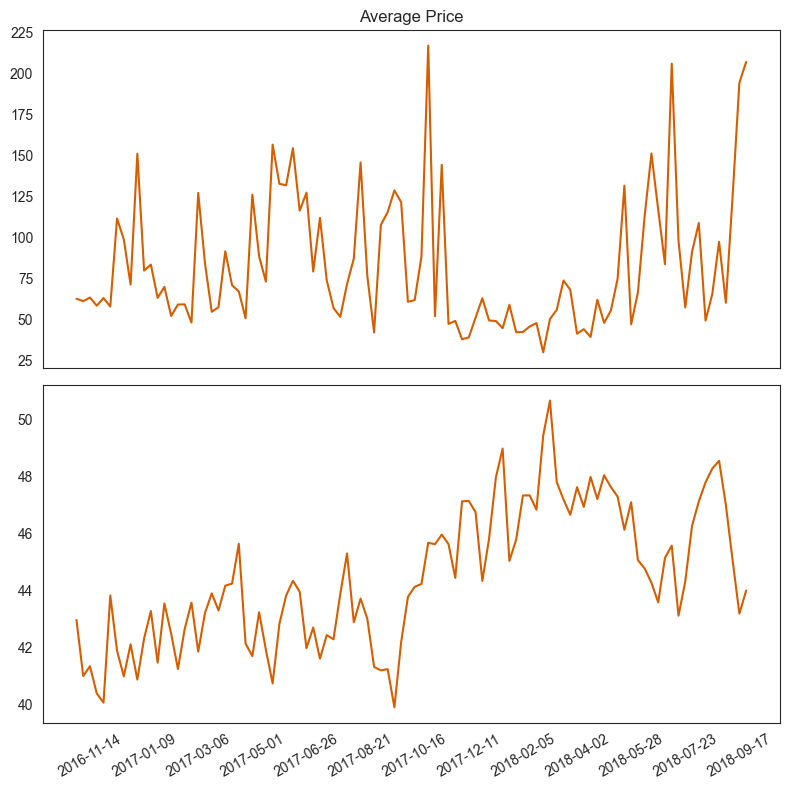

In [99]:
# simple data to display in various forms
x = avg['week']
y = avg['weekly_sales']
z = avg['price']

plt.rcParams['figure.figsize'] = (8,8)
f,axarr = plt.subplots(2,sharex=True)

axarr[0].plot(x,y, color=color)
plt.xticks(rotation=30)
axarr[0].set_title('Average Sales')
axarr[0].set(xticks=avg.week[2::8])#

axarr[1].plot(x,z, color=color)
plt.xticks(rotation=30)
axarr[0].set_title('Average Price')
axarr[0].set(xticks=avg.week[2::8])#

plt.tight_layout()
plt.show()

#plt.savefig("Average_P_S.png",dpi=400,bbox_inches = 'tight')


##### It should be clear that the price value affects the sales, so that a higher price typically leads to a lower level of sales.
##### (We could potentially compute the correlations value = Pearson correlation coefficient)

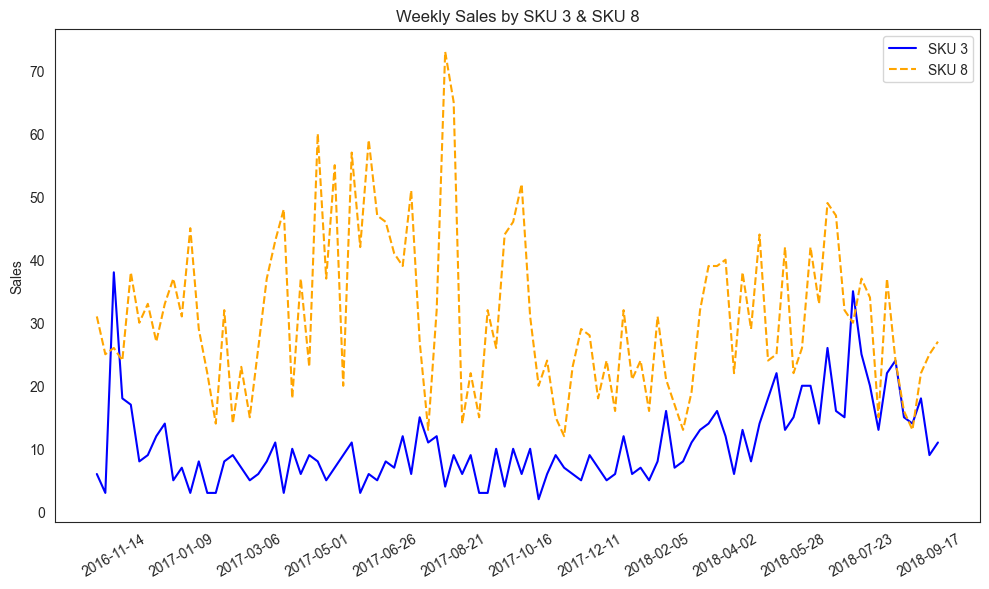

In [97]:
sku3 = sales[sales.sku == 3]
sku8 = sales[sales.sku == 8]

plt.figure(figsize=(10, 6))

plt.plot(sku3['week'], sku3['weekly_sales'], color='blue', label='SKU 3')
plt.plot(sku8['week'], sku8['weekly_sales'], color='orange', label='SKU 8', linestyle='--')

plt.title('Weekly Sales by SKU 3 & SKU 8')
plt.ylabel('Sales')
plt.legend()

ax = plt.gca()
ax.set(xticks=avg['week'][2::8])
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()
# plt.savefig("Sales_2.png",dpi=400,bbox_inches = 'tight')

##### The graph shows that not all SKUs behave the same:
##### - SKU 3: Product with stable low demand (small and constant sales).
##### - SKU 8: Product with volatile high demand (large sales but with strong fluctuations).

**(FOR THIS PROJECT WE ASSUME SALES = DEMAND = this means that the retailer can satisfy all the demand by having sufficient inventory.)**

## Separation between the training and test sets of data to predict demand

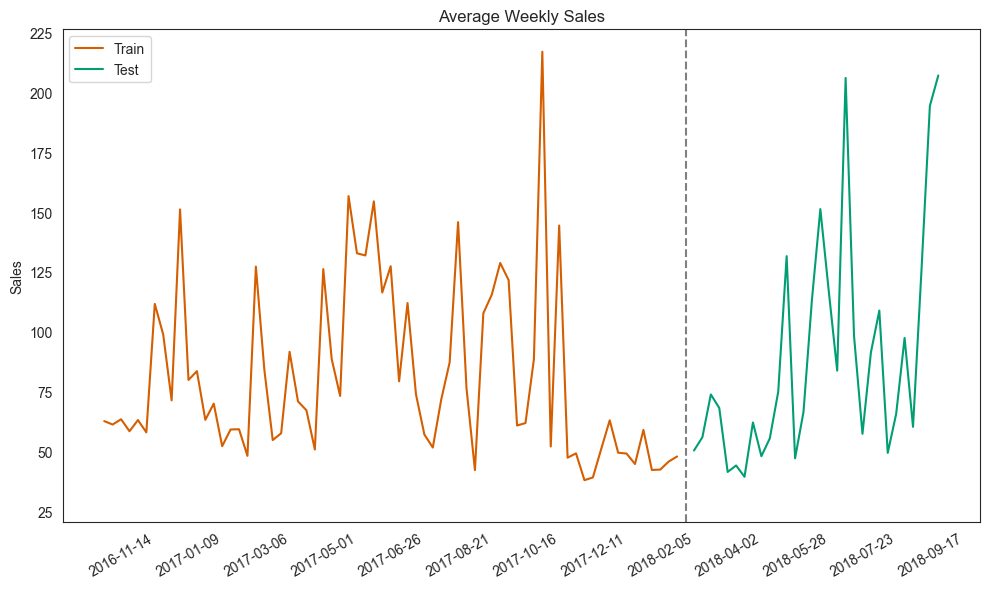

In [103]:
plt.figure(figsize=(10,6))

plt.plot(avg.iloc[:69]["week"], avg.iloc[:69]["weekly_sales"], color=sns.color_palette(palette='colorblind')[3], label="Train")
plt.plot(avg.iloc[69]["week"], avg.iloc[69]["weekly_sales"], color=sns.color_palette(palette='colorblind')[1])
plt.plot(avg.iloc[70:]["week"], avg.iloc[70:]["weekly_sales"], color=sns.color_palette(palette='colorblind')[2], label="Test")

plt.title('Average Weekly Sales')
plt.ylabel("Sales")
plt.axvline(x=avg.iloc[69]["week"], color='gray', linestyle='--')
plt.legend()

ax = plt.gca()
ax.set(xticks=avg['week'][2::8])
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()
# plt.savefig("Sales_split.png", dpi=400, bbox_inches='tight')